# Low-Rank Structure in Gaussian Covariances

This notebook explores how low-rank changes in Gaussian coefficient matrices affect covariance structure.
The emphasis is on empirical covariance, eigenvalues, and matrix rank.

## Background

$$
x = W z + \varepsilon,\quad z \sim \mathcal{N}(0, I_k),\quad \varepsilon \sim \mathcal{N}(0, \sigma^2 I_d)
$$

$$
\Sigma = W W^\top + \sigma^2 I_d.
$$

In [117]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.linalg import eigvalsh


rng = np.random.default_rng(0)

In [118]:
d = 40
k = 8
sigma = 0.01
n = 100000

W0 = rng.normal(size=(d, k))
Sigma0 = W0 @ W0.T + sigma**2 * np.eye(d)

## Low-Rank vs Diffuse Coefficient Changes

In [ ]:
rank_star = 2

B = rng.normal(size=(d, rank_star))
A = rng.normal(size=(rank_star, k))
DeltaW_lr = B @ A

D = rng.normal(size=(d, k))
DeltaW_dense = D / np.linalg.norm(D, 'fro') * np.linalg.norm(DeltaW_lr, 'fro')


In [120]:
def sample(W):
    z = rng.normal(size=(n, k))
    eps = sigma * rng.normal(size=(n, d))
    return z @ W.T + eps

In [121]:
S_lr = (sample(W0 + DeltaW_lr).T @ sample(W0 + DeltaW_lr)) / n
S_dense = (sample(W0 + DeltaW_dense).T @ sample(W0 + DeltaW_dense)) / n

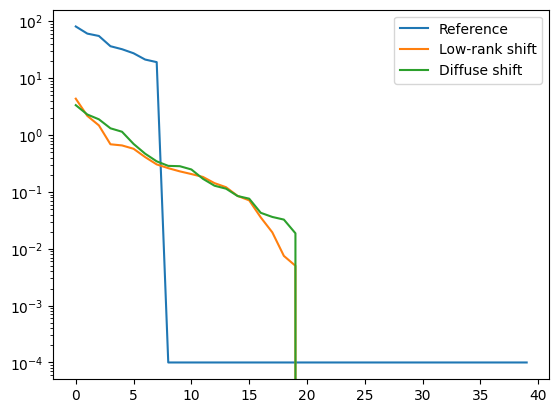

In [122]:
# Compute and sort eigenvalues
eig0 = eigvalsh(Sigma0)
eig_lr = eigvalsh(S_lr)
eig_dense = eigvalsh(S_dense)

# Plot eigenvalues
plt.semilogy(eig0[::-1], label='Reference')
plt.semilogy(eig_lr[::-1], label='Low-rank shift')
plt.semilogy(eig_dense[::-1], label='Diffuse shift')
plt.legend()
plt.show()

Step 3: Quantify “significant change”

In [123]:
threshold = 0.10  # 10% threshold

rel_diff = np.abs(eig_lr - eig0) / eig0
print(f"Number of eigenvalues changed significantly in the low-rank case.{np.sum(rel_diff > threshold)}")

Number of eigenvalues changed significantly in the low-rank case.40


In [124]:
rel_diff = np.abs(eig_dense - eig0) / eig0
print(f"Number of eigenvalues changed significantly in the diffuse case.{np.sum(rel_diff > threshold)}")

Number of eigenvalues changed significantly in the diffuse case.40



Step 4: Interpret the results

1. In the low-rank case, how many eigenvalues change substantially, and how does this number relate to the rank of the coefficient modification?
The number of substantially changed eigenvalues is small, approximately equal to rank_star. 

2. In the diffuse case, why are many eigenvalues affected, even though the overall magnitude of the change is the same?
In the diffuse case, many eigenvalues are affected even though the overall magnitude of the change is the same. This is because in diffuse modification, the signal energy is spread across many directions though it is weak. 

3. How do these observations illustrate the idea that matrix rank limits the number of variance directions that can change?
The matrix rank limits how many variance directions can change. A low rank modification concentrates variance into a small space and therefore alters only a few eigenvalues whereas diffusion modification distributes the variance across many directions causing many eigenvalues to change.